In [1]:
import os
import time
import copy
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader

# Check device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [2]:
# --- Configuration ---
data_dir = "data/images"

# ImageNet normalization for pretrained models
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'validation': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# Create DataSets
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x])
                  for x in ['train', 'validation', 'test']}

# Create DataLoaders
dataloaders = {x: DataLoader(image_datasets[x], batch_size=32, shuffle=(x == 'train'), num_workers=2)
               for x in ['train', 'validation', 'test']}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'validation', 'test']}
class_names = image_datasets['train'].classes

print(f"Classes: {class_names}")
print(f"Dataset Sizes: {dataset_sizes}")

Classes: ['melanoma', 'nevus', 'seborrheic_keratosis']
Dataset Sizes: {'train': 56, 'validation': 7, 'test': 12}


In [3]:
# --- Training Function ---

def train_model(model, criterion, optimizer, num_epochs=5):
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    train_loss_history = []
    val_loss_history = []
    val_acc_history = []

    for epoch in range(num_epochs):
        print(f'Epoch {epoch}/{num_epochs - 1}')
        print('-' * 10)

        # Each epoch has a training and validation phase
        for phase in ['train', 'validation']:
            if phase == 'train':
                model.train()  # Set model to training mode
            else:
                model.eval()   # Set model to evaluate mode

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data.
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # Zero the parameter gradients
                optimizer.zero_grad()

                # Forward
                # Track history if only in train
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # Backward + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # Statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            # Deep copy the model
            if phase == 'validation' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
            
            if phase == 'train':
                train_loss_history.append(epoch_loss)
            else:
                val_loss_history.append(epoch_loss)
                val_acc_history.append(epoch_acc)

        print()

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Acc: {best_acc:4f}')

    # Load best model weights
    model.load_state_dict(best_model_wts)
    return model, val_acc_history


In [4]:
# --- 1. Train SqueezeNet ---
print("\n--- Training SqueezeNet ---")

# Load pretrained model
model_sq = models.squeezenet1_1(weights='IMAGENET1K_V1')

# Modify Final Layer
# SqueezeNet's classifier is a Sequential block. The final Conv2d is at index 1.
# Original: Conv2d(512, 1000, kernel_size=(1, 1), stride=(1, 1))
model_sq.classifier[1] = nn.Conv2d(512, len(class_names), kernel_size=(1, 1), stride=(1, 1))

# Initialize num_classes parameter which SqueezeNet uses in forward pass
model_sq.num_classes = len(class_names)

model_sq = model_sq.to(device)

criterion = nn.CrossEntropyLoss()
# Optimize all parameters
optimizer_sq = optim.SGD(model_sq.parameters(), lr=0.001, momentum=0.9)

# Train
# Keeping epochs low (5) for rapid prototyping, increase for production
model_sq_trained, hist_sq = train_model(model_sq, criterion, optimizer_sq, num_epochs=5)

# Save
torch.save(model_sq_trained.state_dict(), 'squeezenet_skin.pth')
print("SqueezeNet model saved to squeezenet_skin.pth")


--- Training SqueezeNet ---
Epoch 0/4
----------
train Loss: 1.2348 Acc: 0.4286
validation Loss: 1.4697 Acc: 0.4286

Epoch 1/4
----------
train Loss: 0.4698 Acc: 0.8929
validation Loss: 1.8644 Acc: 0.4286

Epoch 2/4
----------
train Loss: 0.4713 Acc: 0.8929
validation Loss: 1.7856 Acc: 0.4286

Epoch 3/4
----------
train Loss: 0.4059 Acc: 0.8929
validation Loss: 1.7224 Acc: 0.4286

Epoch 4/4
----------
train Loss: 0.3759 Acc: 0.9107
validation Loss: 1.7149 Acc: 0.4286

Training complete in 1m 41s
Best val Acc: 0.428571
SqueezeNet model saved to squeezenet_skin.pth


In [5]:
# --- 2. Train ResNet-18 ---
print("\n--- Training ResNet-18 ---")

# Load pretrained model
model_res = models.resnet18(weights='IMAGENET1K_V1')

# Modify Final Layer
# ResNet's fc layer: Linear(in_features=512, out_features=1000, bias=True)
num_ftrs = model_res.fc.in_features
model_res.fc = nn.Linear(num_ftrs, len(class_names))

model_res = model_res.to(device)

criterion = nn.CrossEntropyLoss()
optimizer_res = optim.SGD(model_res.parameters(), lr=0.001, momentum=0.9)

# Train
model_res_trained, hist_res = train_model(model_res, criterion, optimizer_res, num_epochs=5)

# Save
torch.save(model_res_trained.state_dict(), 'resnet_skin.pth')
print("ResNet model saved to resnet_skin.pth")


--- Training ResNet-18 ---
Epoch 0/4
----------
train Loss: 1.3124 Acc: 0.1786
validation Loss: 1.0118 Acc: 0.5714

Epoch 1/4
----------
train Loss: 0.7153 Acc: 0.7679
validation Loss: 1.4334 Acc: 0.4286

Epoch 2/4
----------
train Loss: 0.4293 Acc: 0.8929
validation Loss: 2.1360 Acc: 0.4286

Epoch 3/4
----------
train Loss: 0.4032 Acc: 0.8929
validation Loss: 2.7221 Acc: 0.4286

Epoch 4/4
----------
train Loss: 0.4642 Acc: 0.8929
validation Loss: 3.0684 Acc: 0.4286

Training complete in 1m 45s
Best val Acc: 0.571429
ResNet model saved to resnet_skin.pth



--- Visualizing Explanations (SqueezeNet) ---


/Users/dkopec/Documents/Msc/thesis/fae-models-master-thesis/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True Label: melanoma
Pred Label: melanoma
IG Convergence Delta: tensor([-0.0438])


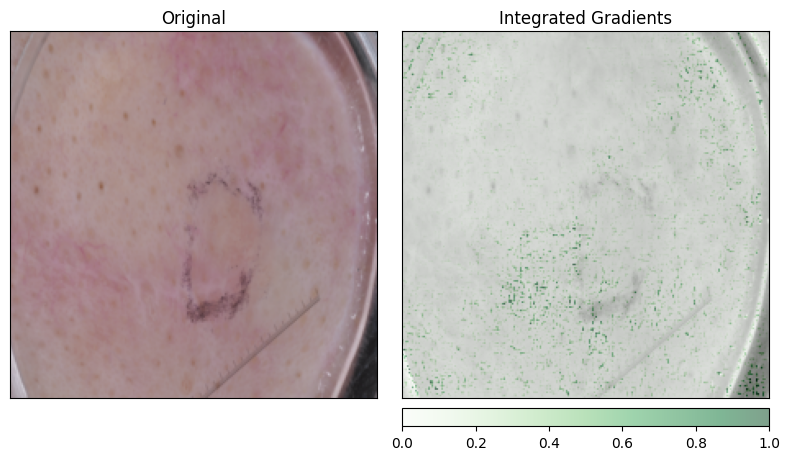

In [6]:
# --- 3. Visualization with Captum (Integrated Gradients) ---
print("\n--- Visualizing Explanations (SqueezeNet) ---")

from captum.attr import IntegratedGradients
from captum.attr import visualization as viz

# Ensure model is in eval mode
model_sq_trained.eval()

# Select a test image
dataiter = iter(dataloaders['test'])
images, labels = next(dataiter)
idx = 0
input_img = images[idx].unsqueeze(0).to(device)
label = labels[idx].item()
pred_label = torch.argmax(model_sq_trained(input_img)).item()

print(f"True Label: {class_names[label]}")
print(f"Pred Label: {class_names[pred_label]}")

# Integrated Gradients
ig = IntegratedGradients(model_sq_trained)
# SqueezeNet input is (1, 3, 224, 224)
# Baseline: black image (all zeros)
attributions_ig, delta = ig.attribute(input_img, target=pred_label, return_convergence_delta=True)

print('IG Convergence Delta:', delta)

# Visualize
# Transpose for matplotlib (C, H, W) -> (H, W, C)
# Denormalize for display
def denormalize(tensor):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = tensor.cpu().numpy().transpose(1, 2, 0)
    img = std * img + mean
    img = np.clip(img, 0, 1)
    return img

original_img = denormalize(images[idx])
attr_ig = np.transpose(attributions_ig.squeeze().cpu().detach().numpy(), (1, 2, 0))

_ = viz.visualize_image_attr_multiple(
    attr_ig,
    original_img,
    ["original_image", "blended_heat_map"],
    ["all", "positive"],
    show_colorbar=True,
    titles=["Original", "Integrated Gradients"],
    fig_size=(8, 6)
)
